1. Title and objective

# CICIoMT2024 - Grouped Multiclass Classification

## Objective
This notebook develops baseline machine learning models for grouped multiclass intrusion detection on the CICIoMT2024 dataset. The grouped multiclass task classifies network traffic into broader attack families:

- Benign
- DDoS
- DoS
- MQTT Attack
- Recon
- Spoofing

The notebook compares a linear baseline and tree-based models, evaluates multiclass performance using macro and weighted metrics, and identifies which grouped attack categories are easiest and hardest to distinguish.

2. Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

3. Display settings

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 1000)

plt.style.use("default")
sns.set_theme(style="whitegrid")

4. Load processed grouped datasets

## Load processed grouped multiclass datasets
Tree-based models use the broader unscaled feature set, while the logistic regression baseline uses the reduced and scaled linear-model feature set.

In [3]:
PROCESSED_DIR = Path("../data/processed")
REPORT_DIR = Path("../reports/results")

X_train_tree = pd.read_csv(PROCESSED_DIR / "X_train_tree_grouped.csv")
X_test_tree = pd.read_csv(PROCESSED_DIR / "X_test_tree_grouped.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train_grouped.csv").squeeze("columns")
y_test = pd.read_csv(PROCESSED_DIR / "y_test_grouped.csv").squeeze("columns")

X_train_linear = pd.read_csv(PROCESSED_DIR / "X_train_linear_grouped_scaled.csv")
X_test_linear = pd.read_csv(PROCESSED_DIR / "X_test_linear_grouped_scaled.csv")

grouped_mapping = pd.read_csv(REPORT_DIR / "grouped_label_mapping.csv")

print("Tree train:", X_train_tree.shape)
print("Tree test:", X_test_tree.shape)
print("Linear train:", X_train_linear.shape)
print("Linear test:", X_test_linear.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

grouped_mapping

Tree train: (2708250, 73)
Tree test: (677063, 73)
Linear train: (2708250, 53)
Linear test: (677063, 53)
y_train: (2708250,)
y_test: (677063,)


,grouped_class_name,grouped_class_code
0,Benign,0
1,DDoS,1
2,DoS,2
3,MQTT Attack,3
4,Recon,4
5,Spoofing,5


5. Create class-name helpers

In [8]:
class_names = grouped_mapping.sort_values("grouped_class_code")["grouped_class_name"].tolist()
class_code_to_name = dict(
    zip(grouped_mapping["grouped_class_code"], grouped_mapping["grouped_class_name"])
)

print("Grouped class names:", class_names)
print("Code to name mapping:", class_code_to_name)

Grouped class names: ['Benign', 'DDoS', 'DoS', 'MQTT Attack', 'Recon', 'Spoofing']
Code to name mapping: {0: 'Benign', 1: 'DDoS', 2: 'DoS', 3: 'MQTT Attack', 4: 'Recon', 5: 'Spoofing'}


6. Confirm grouped target distribution

In [9]:
print("Training grouped target distribution:")
print(y_train.value_counts().sort_index())

print("\nTraining grouped target proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest grouped target distribution:")
print(y_test.value_counts().sort_index())

print("\nTest grouped target proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training grouped target distribution:
target_multiclass_grouped_encoded
0      26096
1       4102
2    1689710
3     524114
4     463385
5        843
Name: count, dtype: int64

Training grouped target proportions:
target_multiclass_grouped_encoded
0    0.009636
1    0.001515
2    0.623912
3    0.193525
4    0.171101
5    0.000311
Name: proportion, dtype: float64

Test grouped target distribution:
target_multiclass_grouped_encoded
0      6524
1      1026
2    422428
3    131029
4    115846
5       210
Name: count, dtype: int64

Test grouped target proportions:
target_multiclass_grouped_encoded
0    0.009636
1    0.001515
2    0.623912
3    0.193526
4    0.171101
5    0.000310
Name: proportion, dtype: float64


In [10]:
train_distribution_named = y_train.map(class_code_to_name).value_counts()
test_distribution_named = y_test.map(class_code_to_name).value_counts()

print("Named train distribution:")
print(train_distribution_named)

print("\nNamed test distribution:")
print(test_distribution_named)

Named train distribution:
target_multiclass_grouped_encoded
DoS            1689710
MQTT Attack     524114
Recon           463385
Benign           26096
DDoS              4102
Spoofing           843
Name: count, dtype: int64

Named test distribution:
target_multiclass_grouped_encoded
DoS            422428
MQTT Attack    131029
Recon          115846
Benign           6524
DDoS             1026
Spoofing          210
Name: count, dtype: int64


7. Helper functions

## Evaluation helpers

In [11]:
def evaluate_multiclass_model(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

In [12]:
def plot_multiclass_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.show()

In [13]:
def classification_report_df(y_true, y_pred, class_names):
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    return pd.DataFrame(report).T

8. Model 1 - Multinomial Logistic Regression

## Model 1: Multinomial Logistic Regression
A class-weighted multinomial logistic regression is used as the linear multiclass baseline.

In [14]:
log_reg_mc = LogisticRegression(
    class_weight="balanced",
    max_iter=1500,
    multi_class="multinomial",
    random_state=42
)

log_reg_mc.fit(X_train_linear, y_train)

y_pred_log = log_reg_mc.predict(X_test_linear)

log_results = evaluate_multiclass_model("Multinomial Logistic Regression", y_test, y_pred_log)
pd.DataFrame([log_results])

c:\Users\jpetr\Desktop\DAMA\extra_projects\iomt-cybersecurity-ml\cybersecurity\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\jpetr\Desktop\DAMA\extra_projects\iomt-cybersecurity-ml\cybersecurity\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Multinomial Logistic Regression,0.987816,0.63919,0.744496,0.654448,0.994296,0.987816,0.990882


In [15]:
log_report_df = classification_report_df(y_test, y_pred_log, class_names)
log_report_df

,precision,recall,f1-score,support
Benign,0.722682,0.789700,0.754706,6524.000000
DDoS,0.079712,0.259259,0.121934,1026.000000
DoS,0.999993,0.996705,0.998346,422428.000000
MQTT Attack,0.994739,0.969678,0.982049,131029.000000
Recon,0.998146,0.994493,0.996316,115846.000000
Spoofing,0.039867,0.457143,0.073338,210.000000
accuracy,0.987816,0.987816,0.987816,0.987816
macro avg,0.639190,0.744496,0.654448,677063.000000
weighted avg,0.994296,0.987816,0.990882,677063.000000


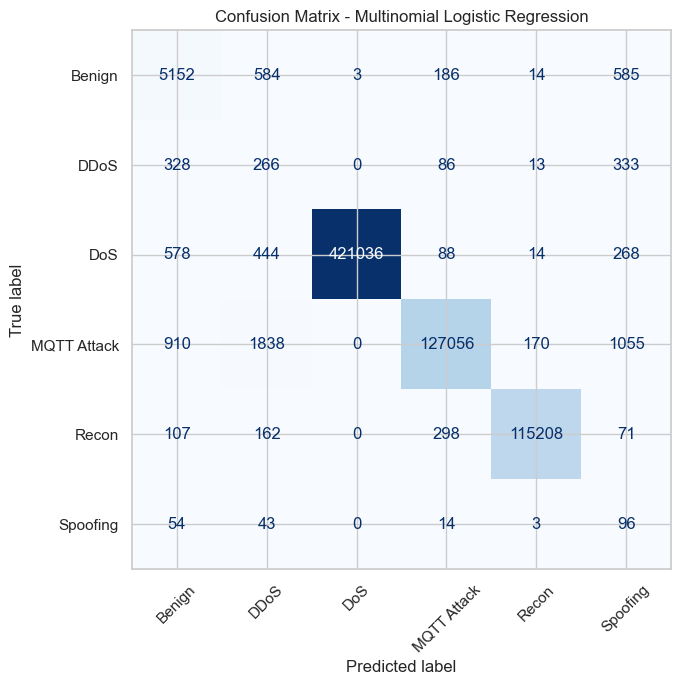

In [16]:
plot_multiclass_confusion(y_test, y_pred_log, class_names, "Confusion Matrix - Multinomial Logistic Regression")

9. Model 2 - Decision Tree

## Model 2: Decision Tree
A class-weighted decision tree provides a nonlinear grouped multiclass baseline.

In [17]:
decision_tree_mc = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=12,
    min_samples_leaf=20,
    random_state=42
)

decision_tree_mc.fit(X_train_tree, y_train)

y_pred_dt = decision_tree_mc.predict(X_test_tree)

dt_results = evaluate_multiclass_model("Decision Tree", y_test, y_pred_dt)
pd.DataFrame([dt_results])

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Decision Tree,0.991211,0.701612,0.848385,0.714955,0.997335,0.991211,0.994085


In [18]:
dt_report_df = classification_report_df(y_test, y_pred_dt, class_names)
dt_report_df

,precision,recall,f1-score,support
Benign,0.913185,0.857756,0.884603,6524.000000
DDoS,0.257030,0.507797,0.341304,1026.000000
DoS,0.999983,0.996870,0.998424,422428.000000
MQTT Attack,0.998375,0.979806,0.989003,131029.000000
Recon,0.999532,0.995701,0.997613,115846.000000
Spoofing,0.041568,0.752381,0.078783,210.000000
accuracy,0.991211,0.991211,0.991211,0.991211
macro avg,0.701612,0.848385,0.714955,677063.000000
weighted avg,0.997335,0.991211,0.994085,677063.000000


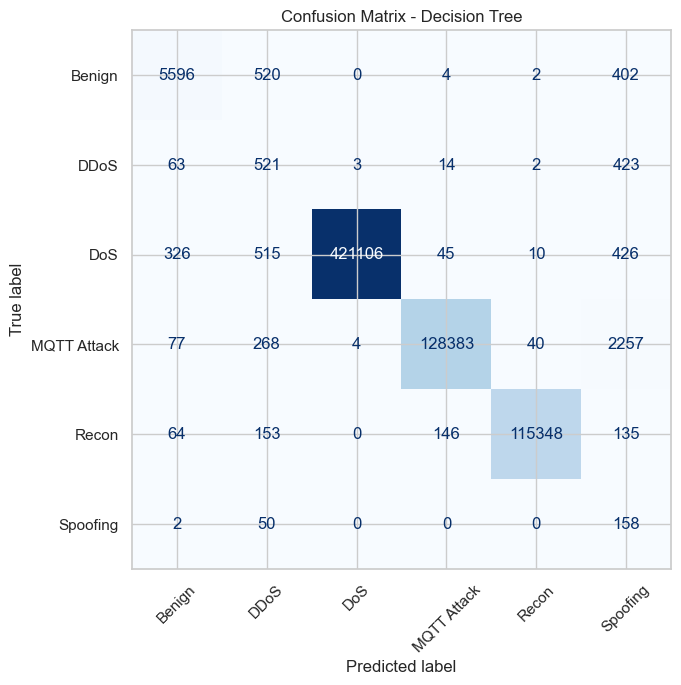

In [19]:
plot_multiclass_confusion(y_test, y_pred_dt, class_names, "Confusion Matrix - Decision Tree")

10. Model 3 - Random Forest

## Model 3: Random Forest
Random Forest is used as the strongest grouped multiclass baseline.

In [20]:
random_forest_mc = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

random_forest_mc.fit(X_train_tree, y_train)

y_pred_rf = random_forest_mc.predict(X_test_tree)

rf_results = evaluate_multiclass_model("Random Forest", y_test, y_pred_rf)
pd.DataFrame([rf_results])

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Random Forest,0.998136,0.901105,0.836679,0.859609,0.998101,0.998136,0.998084


In [21]:
rf_report_df = classification_report_df(y_test, y_pred_rf, class_names)
rf_report_df

,precision,recall,f1-score,support
Benign,0.916655,0.986205,0.950159,6524.000000
DDoS,0.715596,0.608187,0.657534,1026.000000
DoS,0.999268,0.998989,0.999129,422428.000000
MQTT Attack,0.999550,0.999634,0.999592,131029.000000
Recon,0.999698,0.998489,0.999093,115846.000000
Spoofing,0.775862,0.428571,0.552147,210.000000
accuracy,0.998136,0.998136,0.998136,0.998136
macro avg,0.901105,0.836679,0.859609,677063.000000
weighted avg,0.998101,0.998136,0.998084,677063.000000


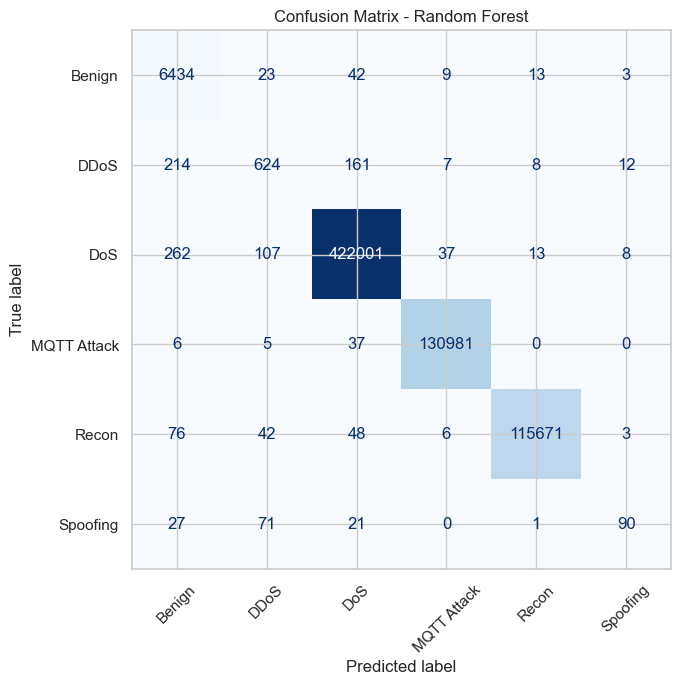

In [22]:
plot_multiclass_confusion(y_test, y_pred_rf, class_names, "Confusion Matrix - Random Forest")

11. Compare grouped multiclass results

In [23]:
results_df = pd.DataFrame([log_results, dt_results, rf_results]).sort_values(
    ["macro_f1", "weighted_f1", "accuracy"], ascending=False
).reset_index(drop=True)

results_df

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Random Forest,0.998136,0.901105,0.836679,0.859609,0.998101,0.998136,0.998084
1,Decision Tree,0.991211,0.701612,0.848385,0.714955,0.997335,0.991211,0.994085
2,Multinomial Logistic Regression,0.987816,0.639190,0.744496,0.654448,0.994296,0.987816,0.990882


12. Per-class F1 comparison

## Per-class F1 comparison
This section compares grouped-class F1-scores across the three models.

In [24]:
per_class_f1_df = pd.DataFrame({
    "class": class_names,
    "logistic_regression_f1": log_report_df.loc[class_names, "f1-score"].values,
    "decision_tree_f1": dt_report_df.loc[class_names, "f1-score"].values,
    "random_forest_f1": rf_report_df.loc[class_names, "f1-score"].values
})

per_class_f1_df

,class,logistic_regression_f1,decision_tree_f1,random_forest_f1
0,Benign,0.754706,0.884603,0.950159
1,DDoS,0.121934,0.341304,0.657534
2,DoS,0.998346,0.998424,0.999129
3,MQTT Attack,0.982049,0.989003,0.999592
4,Recon,0.996316,0.997613,0.999093
5,Spoofing,0.073338,0.078783,0.552147


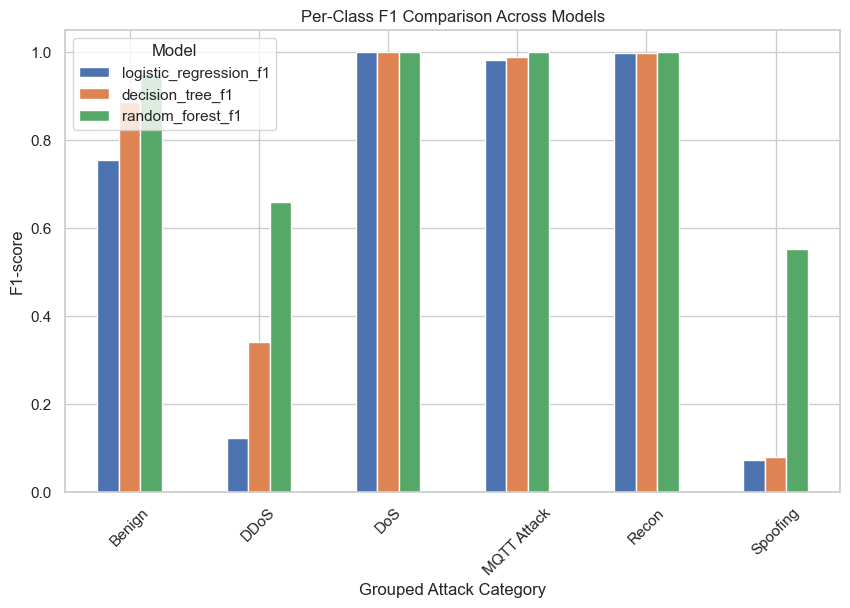

In [25]:
per_class_f1_plot = per_class_f1_df.set_index("class")
per_class_f1_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Per-Class F1 Comparison Across Models")
plt.ylabel("F1-score")
plt.xlabel("Grouped Attack Category")
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.show()

13. Random Forest feature importance

## Random Forest feature importance
Feature importances provide an initial view of the predictors most useful for grouped attack-family classification.

In [26]:
rf_importance = pd.DataFrame({
    "feature": X_train_tree.columns,
    "importance": random_forest_mc.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance.head(20)

,feature,importance
20,Flow IAT Min,0.078693
25,Fwd IAT Min,0.054396
33,Fwd Header Length,0.041416
0,Src Port,0.041105
2,Flow Duration,0.037660
17,Flow IAT Mean,0.034481
44,RST Flag Count,0.034480
15,Flow Bytes/s,0.032986
16,Flow Packets/s,0.032307
62,Bwd Init Win Bytes,0.032271


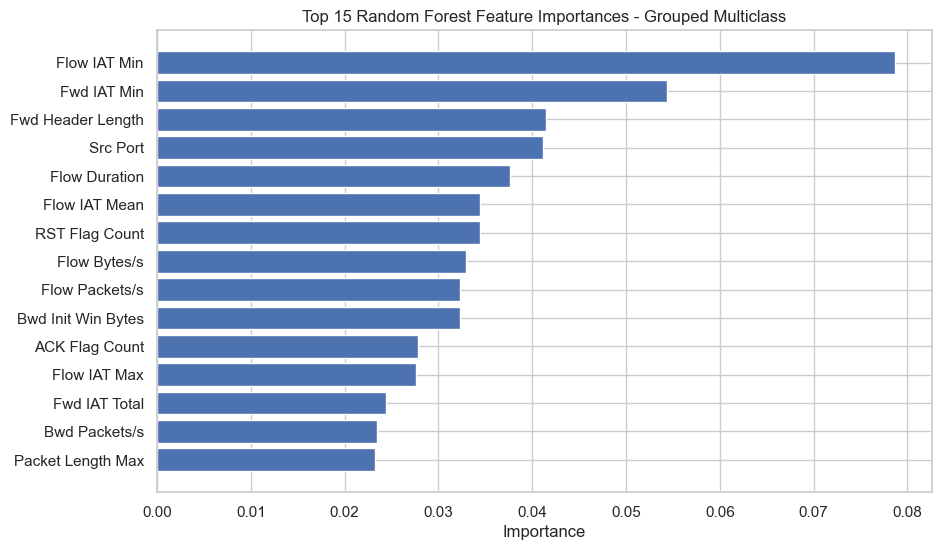

In [27]:
plt.figure(figsize=(10, 6))
top_rf = rf_importance.head(15).sort_values("importance")
plt.barh(top_rf["feature"], top_rf["importance"])
plt.title("Top 15 Random Forest Feature Importances - Grouped Multiclass")
plt.xlabel("Importance")
plt.show()

14. Decision Tree feature importance

In [28]:
dt_importance = pd.DataFrame({
    "feature": X_train_tree.columns,
    "importance": decision_tree_mc.feature_importances_
}).sort_values("importance", ascending=False)

dt_importance.head(15)

,feature,importance
20,Flow IAT Min,0.437862
44,RST Flag Count,0.152695
0,Src Port,0.103191
2,Flow Duration,0.055334
46,ACK Flag Count,0.048381
1,Dst Port,0.041349
36,Bwd Packets/s,0.034497
24,Fwd IAT Max,0.013548
68,Active Min,0.011570
34,Bwd Header Length,0.011457


15. Logistic regression coefficients by class

## Logistic regression coefficient inspection
The largest coefficient magnitudes for each class provide insight into which scaled features contribute most strongly to the multinomial linear baseline.

In [29]:
coef_frames = []

for idx, class_name in enumerate(class_names):
    temp_df = pd.DataFrame({
        "feature": X_train_linear.columns,
        "class_name": class_name,
        "coefficient": log_reg_mc.coef_[idx],
        "abs_coefficient": np.abs(log_reg_mc.coef_[idx])
    }).sort_values("abs_coefficient", ascending=False)
    coef_frames.append(temp_df)

log_coef_all = pd.concat(coef_frames, ignore_index=True)
log_coef_all.head(20)

,feature,class_name,coefficient,abs_coefficient
0,Flow IAT Mean,Benign,4.232436,4.232436
1,Subflow Fwd Packets,Benign,-2.291736,2.291736
2,Packet Length Mean,Benign,2.196605,2.196605
3,Total Fwd Packet,Benign,2.068382,2.068382
4,Active Max,Benign,2.010004,2.010004
5,Bwd Bulk Rate Avg,Benign,1.556578,1.556578
6,PSH Flag Count,Benign,-1.544252,1.544252
7,Total Bwd packets,Benign,-1.524116,1.524116
8,Fwd Act Data Pkts,Benign,1.464319,1.464319
9,Active Mean,Benign,-1.459509,1.459509


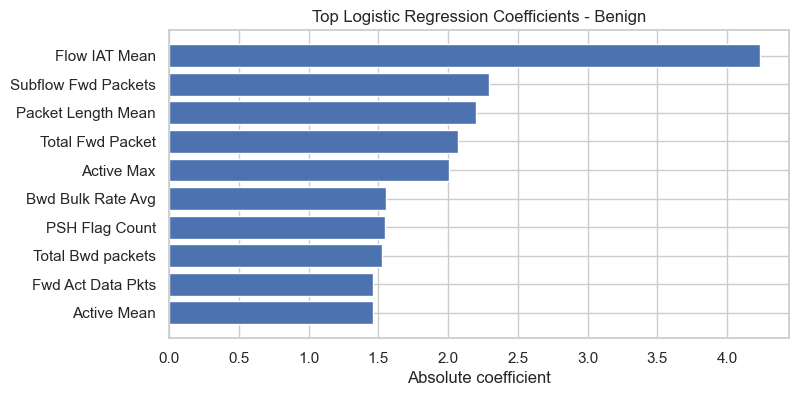

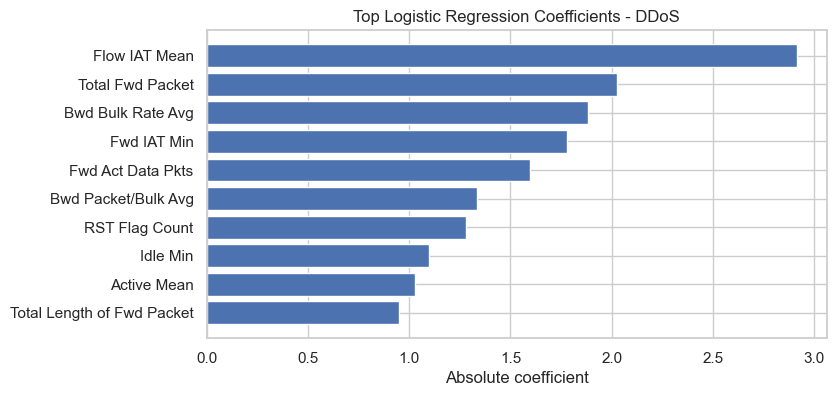

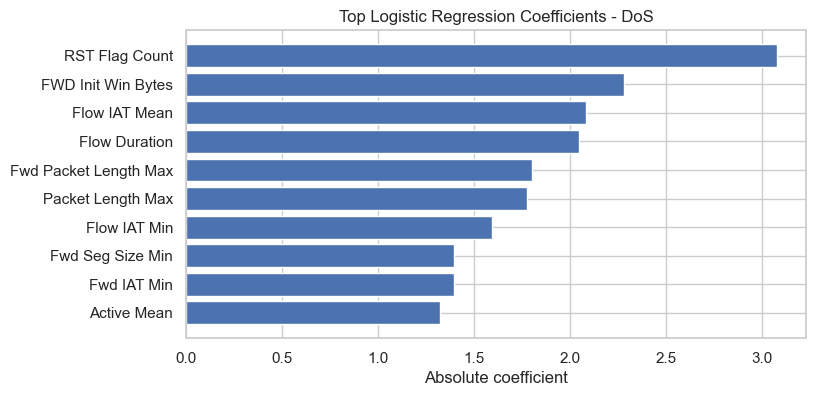

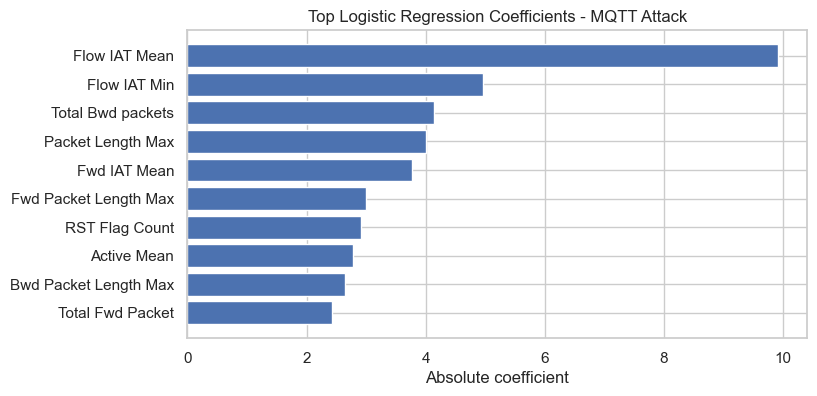

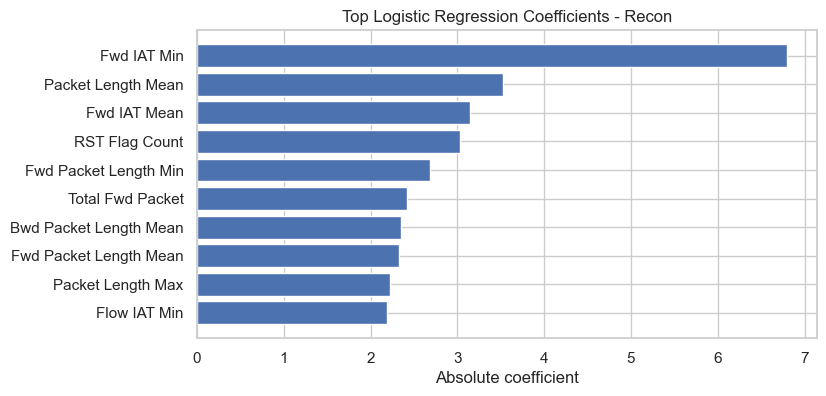

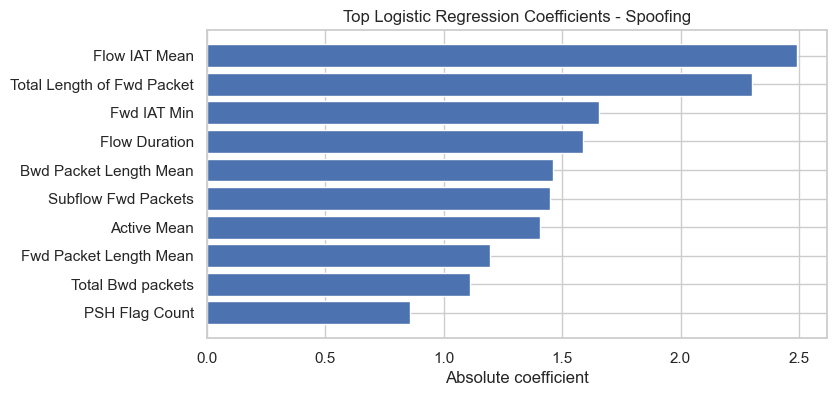

In [30]:
for class_name in class_names:
    top_class_coefs = (
        log_coef_all[log_coef_all["class_name"] == class_name]
        .head(10)
        .sort_values("abs_coefficient")
    )
    
    plt.figure(figsize=(8, 4))
    plt.barh(top_class_coefs["feature"], top_class_coefs["abs_coefficient"])
    plt.title(f"Top Logistic Regression Coefficients - {class_name}")
    plt.xlabel("Absolute coefficient")
    plt.show()

16. Which grouped classes are hardest?

## Hardest grouped classes
This section identifies the grouped classes with the weakest per-class F1 under the strongest model.

In [31]:
rf_per_class = rf_report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
rf_per_class = rf_per_class.sort_values("f1-score")
rf_per_class

,precision,recall,f1-score,support
Spoofing,0.775862,0.428571,0.552147,210.0
DDoS,0.715596,0.608187,0.657534,1026.0
Benign,0.916655,0.986205,0.950159,6524.0
Recon,0.999698,0.998489,0.999093,115846.0
DoS,0.999268,0.998989,0.999129,422428.0
MQTT Attack,0.999550,0.999634,0.999592,131029.0


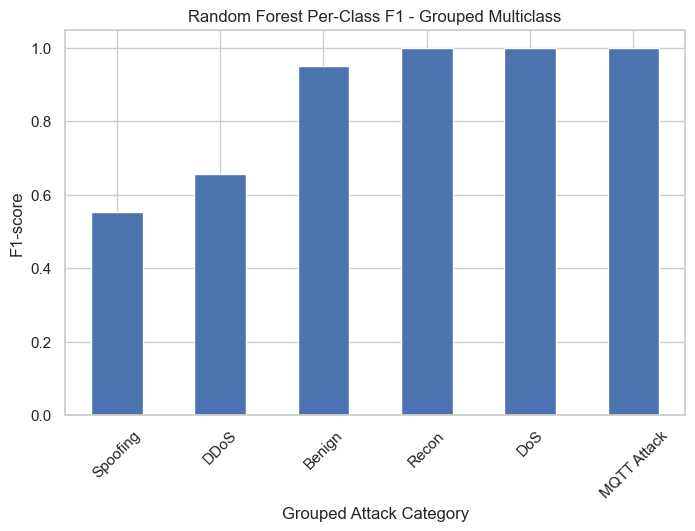

In [32]:
plt.figure(figsize=(8, 5))
rf_per_class["f1-score"].plot(kind="bar")
plt.title("Random Forest Per-Class F1 - Grouped Multiclass")
plt.ylabel("F1-score")
plt.xlabel("Grouped Attack Category")
plt.xticks(rotation=45)
plt.show()

17. Misclassification analysis for the best model

## Misclassification analysis
This section examines the most common grouped-category confusions under the best-performing model.

In [33]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf_df = pd.DataFrame(cm_rf, index=class_names, columns=class_names)
cm_rf_df

,Benign,DDoS,DoS,MQTT Attack,Recon,Spoofing
Benign,6434,23,42,9,13,3
DDoS,214,624,161,7,8,12
DoS,262,107,422001,37,13,8
MQTT Attack,6,5,37,130981,0,0
Recon,76,42,48,6,115671,3
Spoofing,27,71,21,0,1,90


In [34]:
misclassifications = []

for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        if i != j and cm_rf[i, j] > 0:
            misclassifications.append({
                "true_class": true_class,
                "predicted_class": pred_class,
                "count": cm_rf[i, j]
            })

misclass_df = pd.DataFrame(misclassifications).sort_values("count", ascending=False)
misclass_df.head(20)

,true_class,predicted_class,count
10,DoS,Benign,262
5,DDoS,Benign,214
6,DDoS,DoS,161
11,DoS,DDoS,107
18,Recon,Benign,76
24,Spoofing,DDoS,71
20,Recon,DoS,48
1,Benign,DoS,42
19,Recon,DDoS,42
17,MQTT Attack,DoS,37


18. Summary table

In [35]:
summary_df = results_df.copy()
summary_df

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Random Forest,0.998136,0.901105,0.836679,0.859609,0.998101,0.998136,0.998084
1,Decision Tree,0.991211,0.701612,0.848385,0.714955,0.997335,0.991211,0.994085
2,Multinomial Logistic Regression,0.987816,0.639190,0.744496,0.654448,0.994296,0.987816,0.990882


19. Export grouped multiclass results

## Export model  results and models for application

In [36]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(REPORT_DIR / "grouped_multiclass_model_comparison.csv", index=False)
rf_report_df.to_csv(REPORT_DIR / "grouped_multiclass_rf_report.csv")
dt_report_df.to_csv(REPORT_DIR / "grouped_multiclass_dt_report.csv")
log_report_df.to_csv(REPORT_DIR / "grouped_multiclass_log_report.csv")
rf_importance.to_csv(REPORT_DIR / "grouped_multiclass_rf_importance.csv", index=False)
dt_importance.to_csv(REPORT_DIR / "grouped_multiclass_dt_importance.csv", index=False)
log_coef_all.to_csv(REPORT_DIR / "grouped_multiclass_log_coefficients.csv", index=False)
per_class_f1_df.to_csv(REPORT_DIR / "grouped_multiclass_per_class_f1.csv", index=False)
misclass_df.to_csv(REPORT_DIR / "grouped_multiclass_misclassifications.csv", index=False)

print("Grouped multiclass results exported.")

Grouped multiclass results exported.


In [37]:
from pathlib import Path
import pandas as pd

REPORT_DIR = Path("../reports/results")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({"feature": X_train_tree.columns}).to_csv(
    REPORT_DIR / "grouped_rf_features.csv",
    index=False
)

print("Saved grouped_rf_features.csv")

Saved grouped_rf_features.csv


In [38]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(random_forest_mc, MODEL_DIR / "grouped_random_forest.joblib")
print("Saved grouped_random_forest.joblib")

Saved grouped_random_forest.joblib


20. Final summary

## Summary of findings

The grouped multiclass classification task is substantially more difficult than the binary attack-detection task because the model must distinguish among several broader attack families rather than only separating benign from malicious traffic. This makes macro-level evaluation especially important, since strong performance on majority classes can obscure weaker performance on rarer categories.

The linear multinomial logistic regression provides an interpretable multiclass baseline, while the decision tree and random forest capture nonlinear feature interactions. The best-performing model should be selected primarily using macro F1, weighted F1, and the per-class classification report rather than overall accuracy alone.

The grouped setting is particularly useful because it provides a middle ground between the easier binary task and the more challenging full attack-type classification problem. It therefore offers a strong portfolio demonstration of multiclass cybersecurity modeling on IoMT traffic data.

### Interpretation note

If the grouped Random Forest model substantially outperforms the linear baseline, this suggests that the boundaries between broader IoMT attack families are not purely linear and are better captured through nonlinear splits and feature interactions.

### Conclusion

The grouped multiclass results show that broader IoMT attack families can be classified very effectively, especially with nonlinear ensemble methods. Random Forest substantially outperformed both the decision tree and the multinomial logistic regression baseline, particularly in macro-level performance. The model achieved near-perfect classification for the dominant classes DoS, MQTT Attack, and Recon, while performance was lower for the underrepresented DDoS and Spoofing classes. This indicates that the grouped task is highly learnable overall, but rare attack families remain more difficult and require more careful treatment.

Although overall and weighted performance metrics are extremely high, the grouped task remains imbalanced. For this reason, macro F1 and per-class metrics provide a more reliable assessment than accuracy alone. In particular, the weaker results for DDoS and Spoofing show that minority grouped classes remain the main challenge.